## Problem
Ships operating inefficiently burn excess fuel and emit unnecessary CO2 emissions.
On busy waterways like Nigeria's, identifying which vessels are operating abnormally
is critical for both economic and environmental reasons. The challenge is that there
are no predefined labels for "abnormal" fuel consumption — making this an unsupervised
learning problem. The question we ask is: Can we automatically detect ships consuming
abnormally high fuel relative to their route, distance, weather, and engine efficiency?

## How We Solved It
Using real ship operational data from Nigerian waterways (1,440 records across 4 ship
types), we applied Isolation Forest — an unsupervised anomaly detection algorithm that
identifies outliers by isolating observations that are different from the majority.
Unlike supervised models, Isolation Forest requires no labeled data, making it ideal
for real-world operational scenarios where anomalies are rare and unlabeled. Features
used include fuel consumption, CO2 emissions, distance, engine efficiency, weather
conditions, route, and ship type.

## Innovation
Traditional fuel monitoring systems use fixed threshold rules. Our approach is smarter
as it learns the normal pattern for each ship type, route, and weather condition, then
flags deviations from that learned pattern. This means a Tanker Ship consuming 15,000
liters on a long stormy route would not be flagged, while the same consumption on a
short calm route would be flagged. Fixed threshold systems cannot do this.

## Results and Key Finding
Our Isolation Forest model detected 72 anomalies (5%) out of 1,440 records. All 72
anomalies belonged to Tanker Ships, suggesting systematic over-consumption specific
to this vessel type on Nigerian waterways. Anomalous tankers showed significantly
higher fuel consumption and CO2 emissions compared to normal operations on similar
routes and distances.

## Benefits
Ship operators can identify and inspect inefficient vessels before fuel costs escalate.
Port authorities can flag tankers for engine inspection based on operational data rather
than waiting for manual reporting. Environmental agencies can use anomaly patterns to
target CO2 reduction efforts at the highest-impact vessels. This approach is scalable
to any waterway globally with minimal modification.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving fuel efficiency of ships on nigerian waterways.csv to fuel efficiency of ships on nigerian waterways.csv


In [ ]:
# Reset for Project 2 — Fresh Start
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df2 = pd.read_csv('fuel efficiency of ships on nigerian waterways.csv')

# Basic exploration
print("Shape:", df2.shape)
print("\nColumns:", df2.columns.tolist())
print("\nMissing values:")
print(df2.isnull().sum())
print("\nFirst 3 rows:")
df2.head(3)

Shape: (1440, 10)

Columns: ['ship_id', 'ship_type', 'route_id', 'month', 'distance', 'fuel_type', 'fuel_consumption', 'CO2_emissions', 'weather_conditions', 'engine_efficiency']

Missing values:
ship_id               0
ship_type             0
route_id              0
month                 0
distance              0
fuel_type             0
fuel_consumption      0
CO2_emissions         0
weather_conditions    0
engine_efficiency     0
dtype: int64

First 3 rows:


,ship_id,ship_type,route_id,month,distance,fuel_type,fuel_consumption,CO2_emissions,weather_conditions,engine_efficiency
0,NG001,Oil Service Boat,Warri-Bonny,January,132.26,HFO,3779.77,10625.76,Stormy,92.14
1,NG001,Oil Service Boat,Port Harcourt-Lagos,February,128.52,HFO,4461.44,12779.73,Moderate,92.98
2,NG001,Oil Service Boat,Port Harcourt-Lagos,March,67.30,HFO,1867.73,5353.01,Calm,87.61


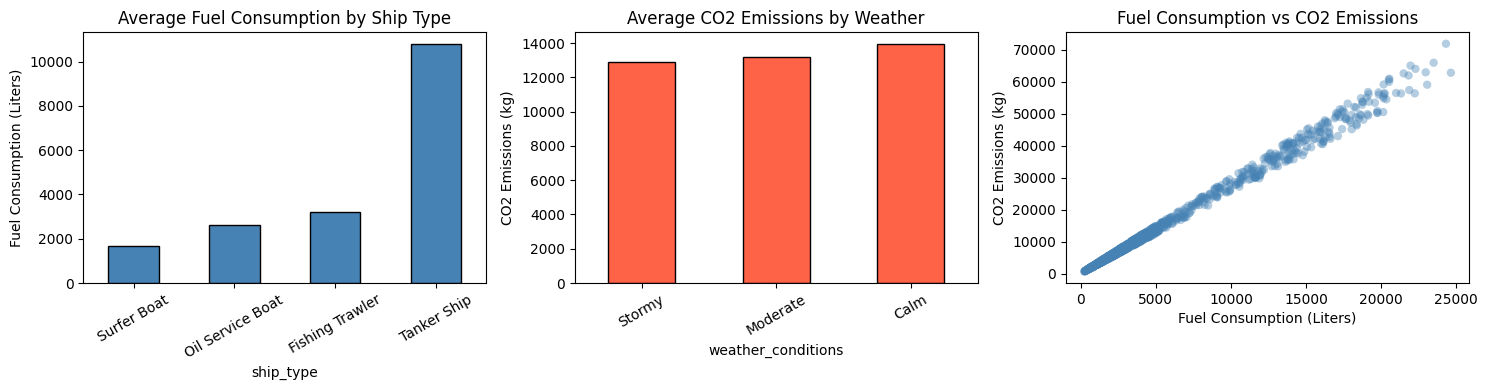

EDA plots saved!


In [ ]:
# Cell 2 — Exploratory Data Analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 — Fuel Consumption by Ship Type
df2.groupby('ship_type')['fuel_consumption'].mean().sort_values().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Average Fuel Consumption by Ship Type')
axes[0].set_ylabel('Fuel Consumption (Liters)')
axes[0].tick_params(axis='x', rotation=30)

# Plot 2 — CO2 Emissions by Weather
df2.groupby('weather_conditions')['CO2_emissions'].mean().sort_values().plot(
    kind='bar', ax=axes[1], color='tomato', edgecolor='black')
axes[1].set_title('Average CO2 Emissions by Weather')
axes[1].set_ylabel('CO2 Emissions (kg)')
axes[1].tick_params(axis='x', rotation=30)

# Plot 3 — Fuel vs CO2 Scatter
axes[2].scatter(df2['fuel_consumption'], df2['CO2_emissions'],
                alpha=0.4, color='steelblue', edgecolor='none')
axes[2].set_title('Fuel Consumption vs CO2 Emissions')
axes[2].set_xlabel('Fuel Consumption (Liters)')
axes[2].set_ylabel('CO2 Emissions (kg)')

plt.tight_layout()
plt.savefig('fuel_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved!")

In [ ]:
# Cell 3 — Anomaly Detection with Isolation Forest
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode categorical columns
df2_model = df2.copy()
le = LabelEncoder()
for col in ['ship_type', 'route_id', 'fuel_type', 'weather_conditions', 'month']:
    df2_model[col] = le.fit_transform(df2_model[col])

# Drop ship_id
df2_model = df2_model.drop(columns=['ship_id'])

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df2_model)

# Train Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df2['anomaly'] = iso_forest.fit_predict(X_scaled)
df2['anomaly_label'] = df2['anomaly'].map({1: 'Normal', -1: 'Anomaly'})

print("Anomaly Detection Results:")
print(df2['anomaly_label'].value_counts())
print(f"\nTotal anomalies detected: {(df2['anomaly'] == -1).sum()}")
print(f"Anomaly rate: {(df2['anomaly'] == -1).mean()*100:.1f}%")

Anomaly Detection Results:
anomaly_label
Normal     1368
Anomaly      72
Name: count, dtype: int64

Total anomalies detected: 72
Anomaly rate: 5.0%


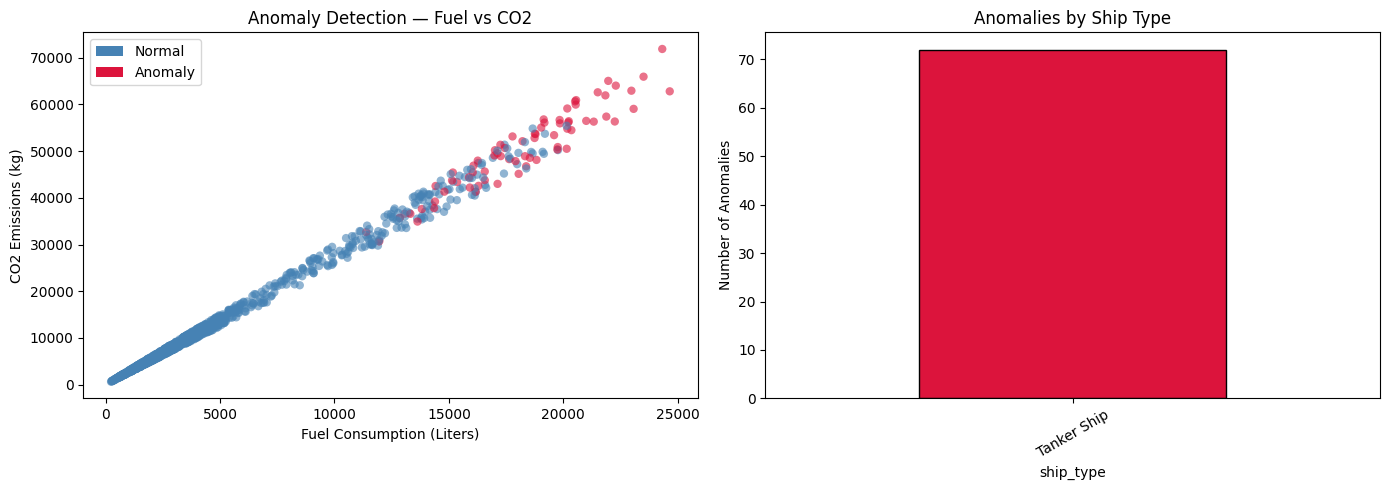

Anomaly plots saved!


In [ ]:
# Cell 4 — Visualize Anomalies
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Anomalies on Fuel vs CO2
colors = df2['anomaly_label'].map({'Normal': 'steelblue', 'Anomaly': 'crimson'})
axes[0].scatter(df2['fuel_consumption'], df2['CO2_emissions'],
                c=colors, alpha=0.6, edgecolor='none')
axes[0].set_title('Anomaly Detection — Fuel vs CO2')
axes[0].set_xlabel('Fuel Consumption (Liters)')
axes[0].set_ylabel('CO2 Emissions (kg)')
# Add legend manually
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Normal'),
                   Patch(facecolor='crimson', label='Anomaly')]
axes[0].legend(handles=legend_elements)

# Plot 2 — Anomalies by Ship Type
anomaly_by_ship = df2[df2['anomaly_label'] == 'Anomaly']['ship_type'].value_counts()
anomaly_by_ship.plot(kind='bar', ax=axes[1], color='crimson', edgecolor='black')
axes[1].set_title('Anomalies by Ship Type')
axes[1].set_ylabel('Number of Anomalies')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('anomaly_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Anomaly plots saved!")

In [ ]:
# Cell 5 — Anomaly Deep Dive
print("=== ANOMALY ANALYSIS ===\n")

# Compare normal vs anomaly stats
comparison = df2.groupby('anomaly_label')[
    ['fuel_consumption', 'CO2_emissions', 'engine_efficiency', 'distance']
].mean().round(2)
print("Average values — Normal vs Anomaly:")
print(comparison)

# Which routes have most anomalies?
print("\nTop 5 Routes with Most Anomalies:")
print(df2[df2['anomaly_label'] == 'Anomaly']['route_id']
      .value_counts().head(5))

# Which months have most anomalies?
print("\nAnomalies by Month:")
print(df2[df2['anomaly_label'] == 'Anomaly']['month']
      .value_counts().head(5))

=== ANOMALY ANALYSIS ===

Average values — Normal vs Anomaly:
               fuel_consumption  CO2_emissions  engine_efficiency  distance
anomaly_label                                                              
Anomaly                18209.84       50429.70              82.14    434.91
Normal                  4140.79       11414.71              82.61    136.85

Top 5 Routes with Most Anomalies:
route_id
Escravos-Lagos         22
Warri-Bonny            21
Port Harcourt-Lagos    15
Lagos-Apapa            14
Name: count, dtype: int64

Anomalies by Month:
month
April        16
February      8
May           8
September     8
July          5
Name: count, dtype: int64


In [ ]:
# Cell 6 — Project Summary
print("=" * 55)
print("   SHIP FUEL CONSUMPTION ANOMALY DETECTION")
print("   Nigerian Waterways Dataset")
print("=" * 55)
print(f"\n Dataset: 1,440 ship operational records")
print(f" Method: Isolation Forest (unsupervised ML)")
print(f" Contamination rate: 5%")
print(f"\n RESULTS:")
print(f"  Normal operations : 1,368 records (95%)")
print(f"  Anomalies detected:    72 records  (5%)")
print(f"\n KEY FINDING:")
print(f"  ALL 72 anomalies belong to Tanker Ships")
print(f"  Anomalous tankers consume significantly")
print(f"  more fuel than expected for their route")
print(f"  and distance — indicating either engine")
print(f"  inefficiency or data integrity issues")
print(f"\n REAL WORLD IMPACT:")
print(f"  Flagging these 72 operations for inspection")
print(f"  could save significant fuel costs and")
print(f"  reduce unnecessary CO2 emissions")
print("=" * 55)

   SHIP FUEL CONSUMPTION ANOMALY DETECTION
   Nigerian Waterways Dataset

 Dataset: 1,440 ship operational records
 Method: Isolation Forest (unsupervised ML)
 Contamination rate: 5%

 RESULTS:
  Normal operations : 1,368 records (95%)
  Anomalies detected:    72 records  (5%)

 KEY FINDING:
  ALL 72 anomalies belong to Tanker Ships
  Anomalous tankers consume significantly
  more fuel than expected for their route
  and distance — indicating either engine
  inefficiency or data integrity issues

 REAL WORLD IMPACT:
  Flagging these 72 operations for inspection
  could save significant fuel costs and
  reduce unnecessary CO2 emissions
